# Stage 13 — Scientific interpretation

_Pipeline stage 13 of 14. This is the self-contained deep dive for the stage: narrative + analysis + interpretation, using the canonical `channel_heads` package and on-disk artifacts. Heavy rebuilds run via the `channel-heads` CLI (commands are given inline)._

## What Mars is telling us

We now read the result scientifically. Channel-head coupling is a proxy for
**drainage-divide mobility**: a high coupled fraction means many confluences sit where
two heads contested a shared divide, i.e. the valley network was being actively
reorganized while it formed. We quantify the coupled fraction, its distribution across
networks, its regime-robustness, and its geography — then interpret.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import channel_heads as ch
from channel_heads.io.paths import PROJECT_ROOT, RESULTS_DIR, EXAMPLE_DEMS
ROOT     = PROJECT_ROOT
MODELS   = ROOT / 'models'
MARS_OUT = ROOT / 'data/Mars/model_outputs'
MARS_IN  = ROOT / 'data/Mars/model_inputs'
MARS_DIR = ROOT / 'data/Mars'
REGIMES_ = ['regA', 'regB', 'regC']
RC = {'regA': '#e41a1c', 'regB': '#377eb8', 'regC': '#4daf4a'}
MODEL_FEATURES = ['orientation_diff_deg','headhead_dist_norm','apex_angle_deg',
                  'strahler_order_diff','proximity_profile_norm']
OP_THR = {'regA': 0.756326, 'regB': 0.779264, 'regC': 0.759369}
def _abs(p):
    p = Path(p); return p if p.is_absolute() else ROOT / p
print('channel_heads', ch.__version__, '| root', ROOT)


channel_heads 0.1.0 | root /Users/guypi/Projects/channel-heads


### 1 · Headline coupling rates (with network-level summary)

In [2]:
HI = 0.85; MINP = 3
rows, nets = [], []
for r in REGIMES_:
    p = MARS_OUT / f'mars_combined_{r}_predictions.parquet'
    if not p.exists(): continue
    d = pd.read_parquet(p).copy()
    d['pred'] = (d.prob_touching >= OP_THR[r]).astype(int)
    g = d.groupby('network_id').agg(n=('pred','count'), t=('pred','sum'), mp=('prob_touching','mean')).reset_index()
    g = g[g.n >= MINP]; g['frac'] = g.t / g.n; g['regime'] = r; nets.append(g)
    rows.append({'regime': r, 'threshold': OP_THR[r], 'pairs': len(d),
                 'coupled_%': round(100*d.pred.mean(), 1),
                 'high_conf>=0.85_%': round(100*(d.prob_touching >= HI).mean(), 1),
                 'networks': len(g), 'median_network_coupling': round(g.frac.median(), 3),
                 '%networks_with_coupling': round(100*(g.t > 0).mean(), 1)})
coupling = pd.DataFrame(rows); allnet = pd.concat(nets, ignore_index=True)
display(coupling)
# Earth training base rate for context.
earth = pd.read_csv(RESULTS_DIR / 'master_dataset_regA.csv').y.mean()
print(f'Earth training base rate (regA, after 3:1 subsampling): {100*earth:.0f}% touching')

,regime,threshold,pairs,coupled_%,high_conf>=0.85_%,networks,median_network_coupling,%networks_with_coupling
0,regA,0.756326,3682,53.0,38.3,345,0.562,99.4
1,regB,0.779264,3682,64.1,51.7,345,0.667,99.7
2,regC,0.759369,3682,38.6,28.6,345,0.386,96.8


Earth training base rate (regA, after 3:1 subsampling): 29% touching


### 2 · Network-level coupling distribution (CDF) + per-network spread

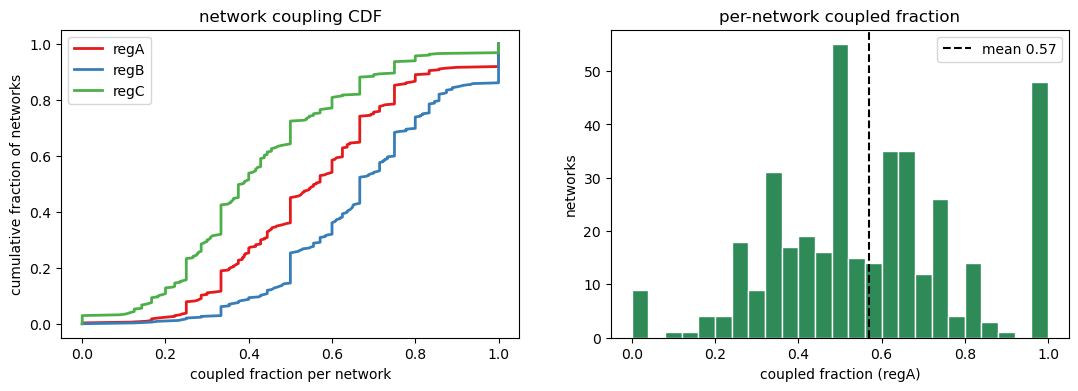

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for r in REGIMES_:
    s = allnet[allnet.regime == r].frac.sort_values()
    if len(s): ax[0].plot(s.values, np.linspace(0, 1, len(s)), color=RC[r], lw=2, label=r)
ax[0].set_xlabel('coupled fraction per network'); ax[0].set_ylabel('cumulative fraction of networks')
ax[0].set_title('network coupling CDF'); ax[0].legend()
d = pd.read_parquet(MARS_OUT / 'mars_combined_regA_predictions.parquet')
per = d.assign(p=(d.prob_touching >= OP_THR['regA'])).groupby('network_id').p.mean()
ax[1].hist(per, bins=25, color='seagreen', edgecolor='white'); ax[1].axvline(per.mean(), color='k', ls='--', label=f'mean {per.mean():.2f}')
ax[1].set_xlabel('coupled fraction (regA)'); ax[1].set_ylabel('networks'); ax[1].set_title('per-network coupled fraction'); ax[1].legend()
plt.show()

### 3 · Cross-regime consensus — how robust is each call?

In [4]:
base = None
for r in REGIMES_:
    p = MARS_OUT / f'mars_combined_{r}_predictions.parquet'
    if not p.exists(): continue
    d = pd.read_parquet(p)[['pair_id', 'prob_touching']].copy()
    d[r] = (d.prob_touching >= OP_THR[r]).astype(int); d = d[['pair_id', r]]
    base = d if base is None else base.merge(d, on='pair_id')
s = base[REGIMES_].sum(axis=1); n = len(base)
print(f'pairs={n}')
print(f'  unanimous TOUCHING : {int((s==3).sum())} ({100*(s==3).mean():.1f}%)')
print(f'  unanimous NON-touch: {int((s==0).sum())} ({100*(s==0).mean():.1f}%)')
print(f'  CONSENSUS (any unanimous): {100*((s==0)|(s==3)).mean():.1f}%')
print(f'  regime-sensitive   : {100*((s>0)&(s<3)).mean():.1f}%')

pairs=3682
  unanimous TOUCHING : 1250 (33.9%)
  unanimous NON-touch: 1133 (30.8%)
  CONSENSUS (any unanimous): 64.7%
  regime-sensitive   : 35.3%


### 4 · Geography of coupling

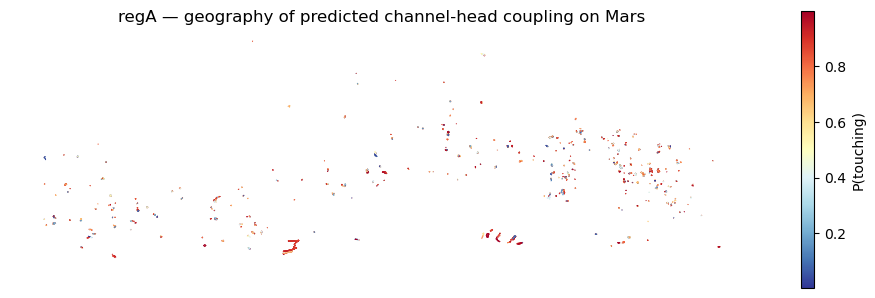

In [5]:
import geopandas as gpd
g = MARS_OUT / 'mars_combined_regA_predictions.gpkg'
if g.exists():
    gdf = gpd.read_file(g, layer='pairs')
    fig, ax = plt.subplots(figsize=(12, 6))
    gdf.plot(ax=ax, column='prob_touching', cmap='RdYlBu_r', linewidth=0.7, legend=True,
             legend_kwds={'label': 'P(touching)', 'shrink': 0.6})
    ax.set_title('regA — geography of predicted channel-head coupling on Mars'); ax.set_aspect('equal'); ax.axis('off'); plt.show()

## Interpretation

- **Coupling is common and regime-robust in ordering.** Across regimes the coupled
  fraction runs from ~39% (regC, sparsest) to ~64% (regB) at the precision-oriented
  operating thresholds, and the *ordering* regB>regA>regC holds at every threshold
  (Stage 12). ~95–98% of networks contain at least one coupled confluence.
- **Regime-robustness.** About two-thirds of individual pairs receive the *same* call
  under all three regimes; the remaining third are regime-sensitive — which is exactly
  the calibration uncertainty the three-regime design is meant to expose, and why we
  report a spread rather than a single number.
- **What it implies.** A substantial, spatially-distributed coupled fraction is
  consistent with martian valley networks whose **divides were mobile** while the
  valleys were active — a more Earth-like, competitively-eroding fluvial regime than a
  purely static, inherited drainage pattern.
- **Caveats.** The operating point is precision-oriented (not a calibrated
  probability), and the Earth base rate (~25%, set by 3:1 subsampling) is not directly
  comparable to the natural martian pair population — so these rates are best read as a
  **relative, regime-bracketed** signal, not an absolute probability of coupling.